# Lecture 5: Becoming a Backprop Ninja — 手动实现反向传播

> 跟随 Karpathy 的 *Neural Networks: Zero to Hero* 系列第 5 讲。
> 核心挑战：**不用 `loss.backward()`**，亲手为字符级语言模型的每一个操作推导梯度，然后用 autograd 验证。

**学习路线：**
1. **数据准备** — 构建字符级训练数据（与前几讲相同）
2. **网络搭建** — 嵌入层 → 线性层 → BatchNorm → tanh → 输出层 + `cmp()` 梯度检验工具
3. **前向传播** — 刻意拆分为原子操作（加、乘、exp、log...），为手动反传做准备
4. **手动反向传播** — 逐步推导 26 个操作的梯度，全部 `exact: True`
5. **合并反传** — 将多步合成一行（softmax+CE、BatchNorm），理解框架内部做了什么
6. **完整训练** — 用自己的梯度跑 200k 步训练，验证模型确实在学习

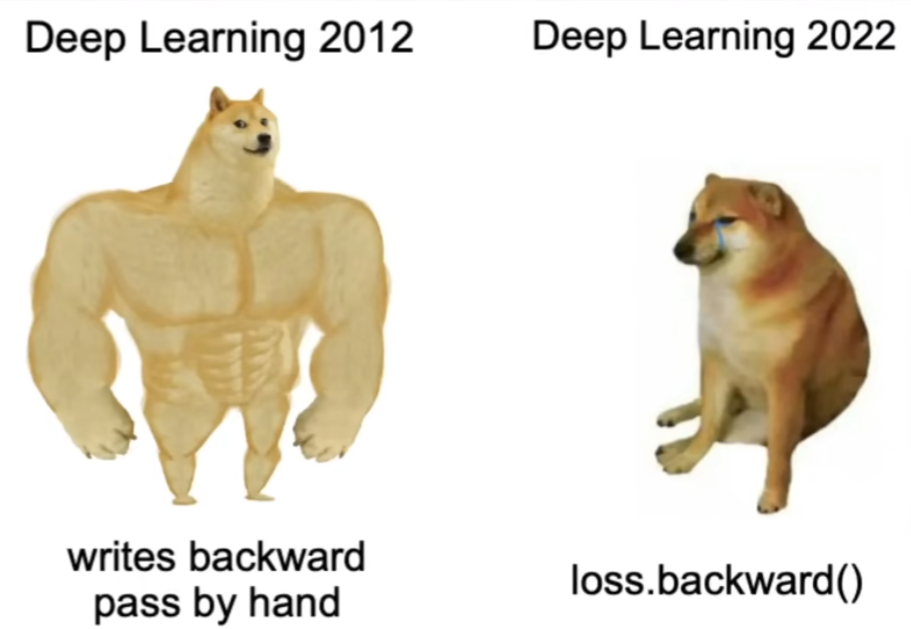

## 1. 数据准备与字符编码

与前几讲相同：读取 32k 个英文名字，构建字符↔索引映射（27 = 26 字母 + 1 个特殊标记 '.'），用滑动窗口切出 (context → next_char) 训练样本，按 80/10/10 划分训练/验证/测试集。

In [1]:
import torch                   # PyTorch：深度学习核心库，提供张量运算和自动求导
import torch.nn.functional as F # F 模块：包含各种不带可学习参数的函数（如交叉熵、softmax等）
import matplotlib.pyplot as plt # matplotlib：绘图库，用于可视化训练过程和结果
# 让图表直接嵌入 notebook 显示，无需调用 plt.show()
%matplotlib inline              

In [2]:
# 读取姓名数据集，每行一个名字，存为列表
words= open('D:\\Vault-4\\Projects\\makemore\\names.txt', 'r').read().splitlines()
print(len(words))              # 数据集中总共有多少个名字（32033个）
print(max(len(w) for w in words)) # 最长的名字有多少个字符（15个）
print(words[:8])               # 预览前8个名字，直观感受数据长什么样

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# --- 构建字符 ↔ 索引的双向映射表 ---
chars= sorted(list(set(''.join(words)))) # 将所有名字拼接→提取不重复字符→排序，得到 a-z 共26个字母
stoi= {s:i+1 for i,s in enumerate(chars)} # 字符→索引：a=1, b=2, ..., z=26（预留0给特殊字符）
stoi['.']=0                               # '.' 作为序列的起始/结束标记，索引设为 0
itos= {i:s for s,i in stoi.items()}       # 索引→字符：反向映射，用于把模型输出转回可读字符
vocab_size= len(stoi)                     # 词表大小 = 27（26个字母 + 1个特殊标记'.'）
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# --- 构建训练/验证/测试数据集 ---
block_size= 3  # 上下文窗口大小：用前3个字符预测下一个字符

def build_dataset(words):
    """
    将名字列表转换为训练样本 (X, Y)。
    采用滑动窗口方式：每次取 block_size 个字符作为输入，下一个字符作为目标。
    例如 "emma" → 输入/目标对：[...] → e, [..e] → m, [.em] → m, [emm] → a, [mma] → .
    """
    X, Y= [], []
    for w in words:
        context= [0]*block_size       # 初始上下文全为 0（即 '...'），表示序列开头
        for ch in w+'.':              # 遍历名字的每个字符，末尾加 '.' 标记结束
            ix= stoi[ch]              # 当前字符转为索引
            X.append(context)         # 当前上下文作为输入
            Y.append(ix)             # 当前字符作为预测目标
            context= context[1:]+[ix] # 滑动窗口：丢弃最左边字符，右边加入新字符
    X= torch.tensor(X)               # 转为 PyTorch 张量，形状 (样本数, block_size)
    Y= torch.tensor(Y)               # 转为 PyTorch 张量，形状 (样本数,)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)                       # 固定随机种子，确保每次运行划分结果一致
random.shuffle(words)                 # 打乱名字顺序，避免数据有序带来的偏差
n1= int(0.8*len(words))              # 80% 数据用于训练
n2= int(0.9*len(words))              # 10% 用于验证（dev），剩余 10% 用于测试

Xtr, Ytr= build_dataset(words[:n1])   # 训练集：(182625, 3) — 约18万个训练样本
Xdev, Ydev= build_dataset(words[n1:n2]) # 验证集：(22655, 3) — 用于调超参数
Xte, Yte= build_dataset(words[n2:])   # 测试集：(22866, 3) — 最终评估模型性能

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 2. 网络搭建与工具准备

本节准备两样东西：

1. **`cmp()` 梯度检验函数** —— 本节课最重要的工具。它对比你手动算的梯度和 PyTorch autograd 的梯度，判断是 bit-for-bit 精确匹配还是浮点近似匹配。
2. **网络参数初始化 + mini-batch 采样** —— 与 Lecture 4 相同的 MLP 架构（嵌入层 → 线性层 → BatchNorm → tanh → 输出层），只是这次我们要亲手算每一步的梯度。

In [5]:
# --- 梯度检验工具函数 ---
# 用于对比手动计算的梯度（dt）与 PyTorch 自动求导的梯度（t.grad）
# 这是本节课的核心：手动推导反向传播，然后用 autograd 验证正确性
# 参数说明：
#   s  — 字符串标签，打印时标识当前在检查哪个变量（如 "logprobs", "W2"）
#   dt — 你手动推导计算出的梯度张量（d=derivative, t=tensor）
#   t  — 前向传播中的原始张量，t.grad 里存着 PyTorch autograd 自动算出的梯度
# 调用示例：cmp('logprobs', dlogprobs, logprobs)
def cmp(s, dt, t):
    # torch.all(布尔张量)：检查张量中是否"每一个"元素都为 True
    # dt==t.grad 先逐元素比较 → 得到布尔张量 → torch.all 判断是否全部相等（bit-for-bit 精确匹配）
    ex=torch.all(dt==t.grad).item()
    # torch.allclose(a, b)：允许微小浮点误差的近似比较
    # 判定条件：|a_i - b_i| ≤ atol(1e-8) + rtol(1e-5) × |b_i|
    # 手动梯度和 autograd 的计算路径不同，浮点舍入会导致极微小差异，
    # 所以 exact 可能为 False 但 approximate 为 True —— 这就说明推导正确
    app=torch.allclose(dt, t.grad)
    maxdiff=(dt-t.grad).abs().max().item()   # 最大绝对差值：量化两者之间的最大偏差
    # f-string 格式化输出：
    #   {s:15s}         — 变量名左对齐占15字符宽，对齐打印结果方便纵向对比
    #   {str(ex):5s}    — exact 结果占5字符宽（"True " 或 "False"）
    #   {str(app):5s}   — approximate 结果占5字符宽
    #   {maxdiff}       — 最大差值，浮点数原样输出
    # 输出示例：logprobs        | exact:True  | approximate:True  | maxdiff:0.0
    print(f'{s:15s} | exact:{str(ex):5s} | approximate:{str(app):5s} | maxdiff:{maxdiff}')

In [6]:
# --- 初始化网络参数 ---
n_embd= 10    # 字符嵌入维度：每个字符用一个 10 维向量表示
n_hidden= 64  # 隐藏层神经元数量

g=torch.Generator().manual_seed(2147483647) # 固定随机种子，确保参数初始化可复现

# 嵌入矩阵 C：形状 (27, 10)，每行是一个字符的嵌入向量
# 通过 C[索引] 查表即可将字符转为连续向量
C= torch.randn((vocab_size, n_embd),           generator=g)

# === 第一层（隐藏层）===
# W1 形状 (30, 64)：输入 = 3个字符 × 10维嵌入 = 30维 → 64个隐藏神经元
# Kaiming 初始化：乘以 (5/3)/sqrt(fan_in)
#   - 5/3 是 tanh 激活函数的增益系数（补偿 tanh 压缩梯度的效应）
#   - 除以 sqrt(fan_in=30) 保证输出方差稳定，避免梯度爆炸/消失
W1= torch.randn((block_size*n_embd, n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5)
b1= torch.randn(n_hidden,                      generator=g)*0.01 # 偏置初始化为很小的值，接近0

# === 第二层（输出层）===
# W2 形状 (64, 27)：64个隐藏神经元 → 27个输出类别（每个字符一个logit）
W2= torch.randn((n_hidden, vocab_size),        generator=g)*0.1  # 乘 0.1 使初始 logits 较小
b2= torch.randn(vocab_size,                    generator=g)*0.1  # 初始 logits 接近均匀 → 初始 loss ≈ -ln(1/27) ≈ 3.30

# === BatchNorm 参数 ===
# bngain (γ)：缩放因子，初始化为 ~1.0，形状 (1, 64) 可在 hidden 维度上广播
# 这里用 randn*0.1+1.0 而非 torch.ones()，只是在 1.0 附近加了微小随机扰动（约0.7~1.3）
# 两种写法效果几乎一样——PyTorch 官方 nn.BatchNorm 默认就是 γ=ones, β=zeros
bngain=torch.randn((1, n_hidden))*0.1+1.0
# bnbias (β)：偏移因子，初始化为 ~0.0，让网络学习每个神经元的最佳偏移
bnbias=torch.randn((1, n_hidden))*0.1

parameters= [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # 总参数量：4137
for p in parameters:
    p.requires_grad= True  # 开启梯度追踪，反向传播时自动计算每个参数的梯度

4137


In [7]:
# --- 采样一个 mini-batch ---
batch_size= 32
n=batch_size  # n 在后续 BatchNorm 计算中代表批次大小，用于求均值和方差

# 从训练集中随机采样 32 个样本的索引（使用固定 generator 保证可复现）
ix= torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb= Xtr[ix], Ytr[ix]  # 取出对应的输入和目标
# Xb 形状 (32, 3)：32个样本，每个样本是3个字符索引
# Yb 形状 (32,)：32个目标字符索引
print(Xb.shape, Yb.shape)

torch.Size([32, 3]) torch.Size([32])


## 3. 前向传播与手动反向传播

**本讲的核心理念：** 反向传播（backpropagation）不是什么神秘的算法——它就是**链式法则（Chain Rule）的递归应用**。如果你能对 $f(g(x))$ 求导，你就能对任意深度的神经网络求导。

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial g} \cdot \frac{\partial g}{\partial x}$$

整个反向传播就是不断重复这个模式：**上游梯度 × 局部导数**。

**Karpathy 的教学策略：** 把前向传播拆成 20+ 个原子操作，每个操作的导数都是你高中学过的（幂函数、指数、对数、三角函数的求导）。手动算完一个，马上用 `cmp()` 验证——即时反馈让你建立信心，也让 bug 无处藏身。

In [ ]:
# 预览 mini-batch 的输入数据和词表大小
Xb, vocab_size

### 3.1 前向传播：刻意拆分为原子操作

**为什么要拆？** 正常写代码，一行 `F.cross_entropy(logits, Yb)` 就搞定了。但这节课的目标是**理解反向传播的每一步**，所以把前向传播拆成尽可能小的操作——每一步只做一件事（加法、乘法、exp、log……），这样每一步的导数都是简单的初等函数导数。

> **生活类比：** 就像拆解一台机械表——整块表你看不懂内部运作，但把齿轮一个个拆出来，每个齿轮的功能都很简单。反向传播就是按拆解的逆序，逐个齿轮计算梯度。

下面的前向传播结束后，会调用 `loss.backward()` 让 PyTorch 自动算出所有梯度（存在 `.grad` 里），作为后续手动推导的"标准答案"。

In [24]:
# ============================================================
# 前向传播 —— 刻意拆分为细粒度的原子操作
# 目的：后续手动为每一步写反向传播梯度，并用 autograd 验证
# ============================================================

# --- 1. 嵌入层 ---
emb= C[Xb]                        # (32, 3, 10) 查表：每个字符索引 → 10维嵌入向量
embcat= emb.view(emb.shape[0], -1) # (32, 30) 将3个嵌入向量拼接成一个30维向量（展平）

# --- 2. 第一层线性变换（pre-BatchNorm）---
hprebn= embcat @ W1 + b1           # (32, 64) 线性变换：30维输入 → 64维隐藏层（未经BN和激活）

# --- 3. BatchNorm（手动拆解为原子操作）---
# 3a. 计算批次均值：对32个样本求平均，得到每个神经元的均值
bnmeani=1/n * hprebn.sum(0, keepdim=True)    # (1, 64) 批次均值 μ

# 3b. 中心化：每个样本减去批次均值
bndiff= hprebn - bnmeani                     # (32, 64) x - μ

# 3c. 计算方差：中心化值的平方再求均值
bndiff2= bndiff**2                           # (32, 64) (x - μ)²

# 注意：除以 (n-1) 是无偏方差估计（Bessel 校正），与 PyTorch 的 BatchNorm 一致
bnvar= 1/(n-1)* bndiff2.sum(0, keepdim=True) # (1, 64) 批次方差 σ²

# 3d. 方差的逆平方根（加 ε=1e-5 防止除零）
bnvar_inv= (bnvar+1e-5)**-0.5                # (1, 64) 即 1/√(σ² + ε)

# 3e. 标准化：得到均值为0、方差为1的分布
bnraw= bndiff * bnvar_inv                    # (32, 64) 标准化后的值 x̂

# 3f. 仿射变换：γ * x̂ + β（可学习的缩放和偏移）
hpreact= bngain * bnraw + bnbias             # (32, 64) BatchNorm 最终输出

# --- 4. 激活函数 ---
h= torch.tanh(hpreact)             # (32, 64) tanh 将值压缩到 (-1, 1)

# --- 5. 第二层线性变换（输出层）---
logits= h @ W2 + b2                # (32, 27) 每个样本输出27个 logits，对应27个字符

# --- 6. 交叉熵损失（手动拆解，等价于 F.cross_entropy）---
# 6a. 数值稳定性：减去每行最大值，防止 exp() 溢出（不影响 softmax 结果）
logits_maxes= logits.max(1, keepdim=True).values  # (32, 1) 每个样本的最大 logit
norm_logits= logits - logits_maxes                 # (32, 27) 平移后的 logits

# 6b. Softmax 的分子：exp(logit)
counts= norm_logits.exp()                          # (32, 27) 指数化

# 6c. Softmax 的分母：每行 exp 值之和
counts_sum= counts.sum(1, keepdim=True)            # (32, 1) Σ exp(logit)

# 6d. 求倒数（拆出来方便后续手动求导）
counts_sum_inv= counts_sum**-1                     # (32, 1) 1 / Σ exp(logit)

# 6e. 得到概率分布
probs= counts * counts_sum_inv                     # (32, 27) softmax 概率

# 6f. 取对数概率
logprobs=probs.log()                               # (32, 27) log(softmax)

# 6g. 负对数似然损失（NLL）：
# logprobs[range(n), Yb] 是高级索引（fancy indexing）：
#   range(n)=[0,1,...,31] 选行，Yb=[各样本的目标字符索引] 选列
#   → 从每行中精确取出"正确类别"的 log 概率，得到长度为 32 的一维张量
# .mean() 对 32 个样本求平均
# 前面的负号：因为 log(prob) < 0（概率<1），取负变正数；模型越准 → prob越大 → loss越小
# 整体等价于 F.cross_entropy(logits, Yb)
loss=-logprobs[range(n), Yb].mean()                # 标量，即交叉熵损失

# --- 7. 准备反向传播 ---
for p in parameters:
    p.grad= None  # 清空旧梯度（等同于 optimizer.zero_grad()）

# 对所有中间变量调用 retain_grad()：
# 默认情况下 PyTorch 只保留叶子节点（参数）的梯度，
# 中间变量的梯度在 backward() 后会被释放。
# retain_grad() 使它们保留，方便我们用 cmp() 对比验证手动梯度。
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logits_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani, embcat, emb]:
    t.retain_grad()

loss.backward()  # PyTorch 自动反向传播，计算所有 .grad
loss              # 输出损失值 ≈ 3.48

tensor(3.7571, grad_fn=<NegBackward0>)

### 3.2 手动反向传播：逐步推导与验证

下面的大 cell 是本节课的**核心练习**——对前向传播中的每一个原子操作，手动推导其梯度，然后用 `cmp()` 对比 PyTorch autograd 的结果。

**方法论：** 从 loss 出发，沿计算图逆序，每次只处理一个节点：
1. 确定当前节点的**局部导数**（$\frac{\partial \text{output}}{\partial \text{input}}$）
2. 乘以**上游梯度**（链式法则）
3. 如果同一变量被多条路径使用，**梯度累加**

**类比：** 反向传播就像从河口往上游追溯水流——每到一个分叉口（变量被多处使用），你需要把所有支流的贡献加起来。`cmp()` 就是你在每个关卡设置的"检查站"，确认推导没有跑偏。

> **关键模式（反复出现）：**
> - **矩阵乘法** $Y = A @ B$：$\frac{\partial L}{\partial A} = \frac{\partial L}{\partial Y} @ B^T$，$\frac{\partial L}{\partial B} = A^T @ \frac{\partial L}{\partial Y}$
> - **广播求和** 的反面是**广播复制**：前向传播中 `sum(0)` 把 (32,64) → (1,64)，反传时梯度从 (1,64) 广播回 (32,64)
> - **逐元素运算** 的梯度也是逐元素的：$f(x) = x^2$ → $f'(x) = 2x$，形状不变

In [25]:
dlogprobs= torch.zeros_like(logprobs)  # ([32,27]) 手动计算 logprobs 的梯度
dlogprobs[range(n), Yb]= -1/n 
cmp('logprobs', dlogprobs, logprobs)  # ([32,27])  验证 logprobs 的梯度

dlogprobs_probs=1/probs
dprobs= dlogprobs * dlogprobs_probs  # 链式法则：dL/dprobs = dL/dlogprobs * dlogprobs/dprobs
cmp('probs', dprobs, probs)  # ([32,27])  验证 probs 的梯度

dcounts_sum_inv= (dprobs * counts).sum(1, keepdim=True)  # 链式法则：dL/dcounts_sum_inv = Σ(dL/dprobs * dprobs/dcounts_sum_inv)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)  # ([32,1]) 验证 counts_sum_inv 的梯度

dcounts_sum=(-counts_sum**-2) * dcounts_sum_inv  # 链式法则：dL/dcounts_sum = dL/dcounts_sum_inv * dcounts_sum_inv/dcounts_sum
cmp('counts_sum', dcounts_sum, counts_sum)  # ([32,1])

dcounts_1= dcounts_sum*torch.ones_like(counts)  # 链式法则：dL/dcounts = dL/dcounts_sum * dcounts_sum/dcounts
dcounts_2= dprobs * counts_sum_inv  # 链式法则：dL/dcounts = dL/dprobs * dprobs/dcounts
dcounts= dcounts_1 + dcounts_2  # 同一变量的梯度需要累加
cmp('counts', dcounts, counts)  # ([32,27]) 验证 counts 的梯度

dnorm_logits= dcounts * counts  # 链式法则：dL/dnorm_logits = dL/dcounts * dcounts/dnorm_logits
cmp('norm_logits', dnorm_logits, norm_logits)  # ([32,27]) 验证 norm_logits 的梯度

dlogits_maxes=-1*dnorm_logits.sum(1, keepdim=True)  # 链式法则：dL/dlogits_maxes = Σ(dL/dnorm_logits * dnorm_logits/dlogits_maxes)
cmp('logits_maxes', dlogits_maxes, logits_maxes)  # ([32,1]) 验证 logits_maxes 的梯度

dlogits_1= 1*dnorm_logits  # 链式法则：dL/dlogits = dL/dnorm_logits * dnorm_logits/dlogits
max_indices=logits.max(1, keepdim=True).indices  # (32, 1) 每行最大值的索引
one_hot_max= torch.zeros_like(logits).scatter(1, max_indices, 1)  # (32, 27) one-hot 编码：最大值位置为1，其余为0
dlogits_2= dlogits_maxes * one_hot_max  # 链式法则：dL/dlogits = dL/dlogits_maxes * dlogits_maxes/dlogits
dlogits= dlogits_1 + dlogits_2  # 同一变量的梯度需要累加
cmp('logits', dlogits, logits)  # ([32,27]) 验证 logits 的梯度

dh= dlogits @ W2.t()
cmp('h', dh, h)  # ([32,64]) 验证 h 的梯度

dW2= h.t() @ dlogits
cmp('W2', dW2, W2)  # ([64,27])

db2= dlogits.sum(0)
cmp('b2', db2, b2)  # ([27,])

dhpreact= (1-h**2) * dh  # 链式法则：dL/dhpreact = dL/dh * dh/dhpreact，tanh 的导数是 1 - tanh²
cmp('hpreact', dhpreact, hpreact)  # ([32,64]) 验证 hpreact 的梯度

dbngain = (dhpreact * bnraw).sum(0, keepdim=True)  # 链式法则：dL/dbngain = Σ(dL/dhpreact * dhpreact/dbngain)，其中 dhpreact/dbngain = bnraw
cmp('bngain', dbngain, bngain)  # ([1,64]) 验证 bngain 的梯度

dbnraw= dhpreact * bngain  # 链式法则：dL/dbnraw = dL/dhpreact * dhpreact/dbnraw，其中 dhpreact/dbnraw = bngain
cmp('bnraw', dbnraw, bnraw)  # ([32,64]) 验证 bnraw 的梯度

dbnbias=1* dhpreact.sum(0, keepdim=True)  # 链式法则：dL/dbnbias = Σ(dL/dhpreact * dhpreact/dbnbias)，其中 dhpreact/dbnbias = 1
cmp('bnbias', dbnbias, bnbias)  # ([1,64]) 验证 bnbias 的梯度

dbnvar_inv= (dbnraw * bndiff).sum(0, keepdim=True)  # 链式法则：dL/dbnvar_inv = Σ(dL/dbnraw * dbnraw/dbnvar_inv)，其中 dbnraw/dbnvar_inv = bndiff
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)  # ([1,64]) 验证 bnvar_inv 的梯度

dbnvar= -0.5 * (bnvar + 1e-5)**(-1.5) * dbnvar_inv  # 链式法则：dL/dbnvar = dL/dbnvar_inv * dbnvar_inv/dbnvar，其中 dbnvar_inv/dbnvar = -0.5 * (bnvar + ε)^(-1.5)
cmp('bnvar', dbnvar, bnvar)  # ([1,64]) 验证 bnvar 的梯度

dbndiff2= (1/(n-1)) * torch.ones_like(bndiff2) * dbnvar  # 链式法则：dL/dbndiff2 = dL/dbnvar * dbnvar/dbndiff2，其中 dbnvar/dbndiff2 = 1/(n-1)
cmp('bndiff2', dbndiff2, bndiff2)  # ([32,64]) 验证 bndiff2 的梯度

dbndiff_1=bnvar_inv * dbnraw  # 链式法则：dL/dbndiff = dL/dbnraw * dbnraw/dbndiff，其中 dbnraw/dbndiff = bnvar_inv
dbndiff_2= 2*bndiff * dbndiff2  # 链式法则：dL/dbndiff = dL/dbndiff2 * dbndiff2/dbndiff，其中 dbndiff2/dbndiff = 2*bndiff
dbndiff= dbndiff_1 + dbndiff_2  # 同一变量的梯度需要累加
cmp('bndiff', dbndiff, bndiff)  # ([32,64]) 验证 bndiff 的梯度

dbnmeani= -1*dbndiff.sum(0, keepdim=True)  # 链式法则：dL/dbnmeani = Σ(dL/dbndiff * dbndiff/dbnmeani)，其中 dbndiff/dbnmeani = -1
cmp('bnmeani', dbnmeani, bnmeani)  # ([1,64]) 验证 bnmeani 的梯度

dbnrebn_1= dbndiff  # 链式法则：dL/dbnrebn_1 = dL/dbndiff * dbndiff/dbnrebn_1，其中 dbndiff/dbnrebn_1 = 1
dbnrebn_2= (1/n) * torch.ones_like(hprebn) * dbnmeani  # 链式法则：dL/dbnrebn_2 = dL/dbnmeani * dbnmeani/dbnrebn，其中 dbnmeani/dbnrebn = (1/n)
dbnrebn= dbnrebn_1 + dbnrebn_2  # 同一变量的梯度需要累加
cmp('hprebn', dbnrebn, hprebn)  # ([32,64]) 验证 hprebn 的梯度

dembcat= dbnrebn @ W1.t()  # 链式法则：dL/dembcat = dL/dbnrebn * dbnrebn/dembcat，其中 dbnrebn/dembcat = W1^T
cmp('embcat', dembcat, embcat)  # ([32,30])

dW1= embcat.t() @ dbnrebn  # 链式法则：dL/dW1 = dL/dbnrebn * dbnrebn/dW1，其中 dbnrebn/dW1 = embcat^T
cmp('W1', dW1, W1)  # ([30,64])

db1= dbnrebn.sum(0)  # 链式法则：dL/db1 = Σ(dL/dbnrebn * dbnrebn/db1)，其中 dbnrebn/db1 = 1
cmp('b1', db1, b1)  # ([64,])

demb= dembcat.view(emb.shape)  # 将展平的梯度重新变回嵌入层的形状 (32, 3, 10)
cmp('emb', demb, emb)  # ([32,3,10])

dC = torch.zeros_like(C)  # (27, 10) 先初始化为全零，因为不是每个字符都出现在当前 batch 中
# index_add_(dim, index, source)：
#   对于第 i 份 source，把它加到 dC 的第 index[i] 行上
#   等价于：for i in range(96): dC[index[i]] += source[i]
#
# Xb.view(-1)：(32,3) → (96,)  展平为 96 个字符索引，告诉每份梯度该加回 C 的第几行
# demb.view(-1, n_embd)：(32,3,10) → (96,10)  展平为 96 个 10 维梯度向量，与索引一一对应
#
# 例如字符 '.'（索引0）在 batch 中出现了 5 次，
# 则 dC[0] = 这 5 个位置的梯度向量之和
dC.index_add_(0, Xb.view(-1), demb.view(-1, n_embd))
cmp('C', dC, C)  # (27, 10) 验证嵌入矩阵 C 的梯度


logprobs        | exact:True  | approximate:True  | maxdiff:0.0
probs           | exact:True  | approximate:True  | maxdiff:0.0
counts_sum_inv  | exact:True  | approximate:True  | maxdiff:0.0
counts_sum      | exact:True  | approximate:True  | maxdiff:0.0
counts          | exact:True  | approximate:True  | maxdiff:0.0
norm_logits     | exact:True  | approximate:True  | maxdiff:0.0
logits_maxes    | exact:True  | approximate:True  | maxdiff:0.0
logits          | exact:True  | approximate:True  | maxdiff:0.0
h               | exact:True  | approximate:True  | maxdiff:0.0
W2              | exact:True  | approximate:True  | maxdiff:0.0
b2              | exact:True  | approximate:True  | maxdiff:0.0
hpreact         | exact:True  | approximate:True  | maxdiff:0.0
bngain          | exact:True  | approximate:True  | maxdiff:0.0
bnraw           | exact:True  | approximate:True  | maxdiff:0.0
bnbias          | exact:True  | approximate:True  | maxdiff:0.0
bnvar_inv       | exact:True  | approxim

## 4. 合并反传：一步到位

> 上一步把反向传播拆成了 26 个原子操作。这是为了**理解**。
> 但实际工程中，PyTorch 框架会把多个操作合并成一步，既快又省内存。

这一节验证两个关键合并：

1. **Softmax + Cross-Entropy → dlogits**：$\nabla_{\mathbf{l}}\text{loss} = \mathbf{P} - \mathbf{e}_y$（详见附录推导）
2. **BatchNorm 反传 → dhprebn**：7 步合并为 1 个公式（详见附录推导）
3. **BatchNorm 前向 → hpreact**：标准化 + 仿射变换合为 1 行

> **深入理解：** 为什么先拆后合？因为只有亲手实现过原子操作，你才知道合并公式里每一项的来历。
> 如果一上来就用合并公式，它就只是一个"魔法黑箱"——出了 bug 你根本不知道该怀疑哪里。

In [11]:
loss_fast=F.cross_entropy(logits, Yb)  # 使用 PyTorch 内置函数计算交叉熵损失，结果应该与手动计算的 loss 完全一致
print(loss_fast.item(), loss.item(), 'diff:', abs(loss_fast.item() - loss.item()))  # 输出两个损失值，应该完全相同（或非常接近）

3.337862491607666 3.337862491607666 diff: 0.0


In [ ]:
dlogits_fast = probs.clone()        # 先复制一份 P
dlogits_fast[range(n), Yb] -= 1     # 在正确类别位置减 1
dlogits_fast /= n                   # 除以 batch size 取平均
cmp('dlogits (fast)', dlogits_fast, logits)  # 验证：一步完成 softmax+CE 反传，等价于拆解的多步操作

hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
cmp('hpreact (fast)', hpreact_fast, hpreact)  # 验证：一步完成 BatchNorm，等价于拆解的多步操作

In [ ]:
# 查看 dlogits 的原始数值：每行有一个 ~-0.03 的负值（正确类别），其余为 ~+0.001 的小正数
dlogits

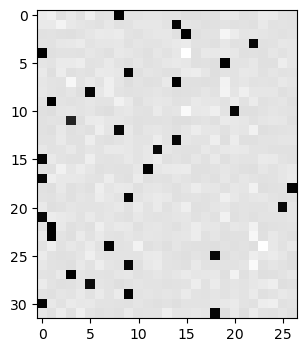

In [15]:
plt.figure(figsize=(12, 4))
plt.imshow(dlogits.detach(), cmap='gray')  # 可视化 dlogits，观察梯度分布（32行对应样本，27列对应类别）

**↑ 上图解读：`dlogits` 梯度热力图**

这张灰度图的形状是 **(32, 27)**，行 = mini-batch 中的 32 个样本，列 = 27 个字符类别。

| 颜色 | 含义 | 公式 |
|------|------|------|
| **均匀的浅灰底色** | 非正确类别的梯度，值为 $P_i / n$（小正数，接近 0） | $i \neq y$：梯度 = $P_i$ → "把这个 logit 往下压" |
| **每行恰好一个黑点** | 正确类别的梯度，值为 $(P_y - 1)/n$（负数，接近 $-1/n$） | $i = y$：梯度 = $P_y - 1$ → "把这个 logit 往上推" |

**关键观察：**

1. **每行有且仅有一个黑点**——对应该样本的正确答案 $y$，梯度为负（鼓励增大该 logit）
2. **黑点的位置是随机散布的**——因为 32 个样本的目标字符各不相同（有的是 'a'、有的是 'e'、有的是 '.'）
3. **灰色底色非常均匀**——模型还没训练好，softmax 输出接近均匀分布 $P_i \approx 1/27$，所以非目标类的梯度都差不多大
4. **如果模型训练收敛**，图会变化：灰色底色会更白（$P_i \to 0$），黑点会变浅（$P_y - 1 \to 0$），意味着梯度越来越小，模型已经学好了

> 这张图就是 $\dfrac{\partial\,\text{loss}}{\partial\,\text{logits}} = \mathbf{P} - \mathbf{e}_y$（除以 $n$ 取平均后）的直观展示。

**为什么"黑 = 往上推"？——参数更新的直觉**

`cmap='gray'` 中值越小越黑。正确类别处梯度为 $(P_y-1)/n$，是负数，所以显示为黑色。

参数更新公式（梯度下降）：

$$l_i \leftarrow l_i - \text{lr} \times \frac{\partial\,\text{loss}}{\partial\, l_i}$$

- **正确类别**（$i=y$）：梯度为负数 → $-\text{lr} \times (\text{负数}) = \text{正数}$ → $l_y$ **变大** → 概率升高 ✓
- **错误类别**（$i \neq y$）：梯度为正数 → $-\text{lr} \times (\text{正数}) = \text{负数}$ → $l_i$ **变小** → 概率降低 ✓

**梯度下降在做一件直觉上很自然的事：把正确答案的分数拉高，把错误答案的分数压低。**

In [20]:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(7.1526e-07, grad_fn=<MaxBackward1>)


In [ ]:
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact:False | approximate:True  | maxdiff:9.313225746154785e-10


**↑ 上面代码的推导过程：BatchNorm 反向传播一步合并**

> 上面的手动反传把 BatchNorm 拆成了 7 个原子操作（`bnmeani → bndiff → bndiff2 → bnvar → bnvar_inv → bnraw → hpreact`）。
> 这里将它们**合并为一个公式**，直接从 $\frac{\partial L}{\partial y_i}$ 得到 $\frac{\partial L}{\partial x_i}$。

### 定义回顾

$$\mu = \frac{1}{m}\sum_i x_i, \qquad \sigma^2 = \frac{1}{m-1}\sum_i(x_i-\mu)^2, \qquad \hat{x}_i = \frac{x_i-\mu}{\sqrt{\sigma^2+\epsilon}}, \qquad y_i = \gamma\hat{x}_i + \beta$$

**已知**：$\frac{\partial L}{\partial y_i}$（代码中的 `dhpreact`），**目标**：$\frac{\partial L}{\partial x_i}$（代码中的 `dhprebn`）

### 计算图：$x_i$ 通过三条路径影响 $L$

```
x_i ──→ x̂_i ──→ y_i      (直接路径)
 │
 ├──→ μ  ──→ x̂_i ──→ y_i  (通过均值)
 │
 └──→ σ² ──→ x̂_i ──→ y_i  (通过方差)
```

按**逆拓扑序**依次求中间梯度 ① → ② → ③，最后汇合得到 ④：

---

### ① $\dfrac{\partial L}{\partial \hat{x}_i} = \dfrac{\partial L}{\partial y_i} \cdot \gamma$

$y_i = \gamma\hat{x}_i + \beta$，直接乘 $\gamma$。

### ② $\dfrac{\partial L}{\partial \sigma^2} = -\dfrac{\gamma}{2}\sum_j \dfrac{\partial L}{\partial y_j}\cdot(x_j-\mu)\cdot(\sigma^2+\epsilon)^{-3/2}$

$\hat{x}_i = (x_i-\mu)(\sigma^2+\epsilon)^{-1/2}$，对 $\sigma^2$ 求导用幂法则得 $-\frac{1}{2}(x_i-\mu)(\sigma^2+\epsilon)^{-3/2}$。

$\sigma^2$ 被所有样本共享，所以对 $j$ 求和。

### ③ $\dfrac{\partial L}{\partial \mu} = -\gamma(\sigma^2+\epsilon)^{-1/2}\sum_j \dfrac{\partial L}{\partial y_j}$

$\mu$ 通过两条路径影响 $L$：

$$\frac{\partial L}{\partial \mu} = \underbrace{\sum_i \frac{\partial L}{\partial \hat{x}_i}\cdot\frac{\partial \hat{x}_i}{\partial \mu}}_{\text{路径 1}} + \underbrace{\frac{\partial L}{\partial \sigma^2}\cdot\frac{\partial \sigma^2}{\partial \mu}}_{\text{路径 2 = 0！}}$$

**路径 2 恒等于零**，因为：

$$\frac{\partial \sigma^2}{\partial \mu} = \frac{-2}{m-1}\sum_i(x_i-\mu) = \frac{-2}{m-1}\!\left(\sum_i x_i - m\mu\right) = \frac{-2}{m-1}(m\mu - m\mu) = 0$$

> $\mu$ 恰好使 $\sum(x_i - \mu) \equiv 0$（这就是均值的定义），所以方差对均值的一阶导数为零。

因此只剩路径 1，其中 $\frac{\partial \hat{x}_i}{\partial \mu} = -(\sigma^2+\epsilon)^{-1/2}$。

---

### ④ 三条路径汇合

$$\frac{\partial L}{\partial x_i} = \frac{\partial L}{\partial \hat{x}_i}\cdot\underbrace{\frac{\partial \hat{x}_i}{\partial x_i}}_{(\sigma^2+\epsilon)^{-1/2}} + \;\frac{\partial L}{\partial \mu}\cdot\underbrace{\frac{\partial \mu}{\partial x_i}}_{1/m} + \;\frac{\partial L}{\partial \sigma^2}\cdot\underbrace{\frac{\partial \sigma^2}{\partial x_i}}_{\frac{2}{m-1}(x_i-\mu)}$$

将 ①②③ 全部代入，用 $\hat{x}_i = \frac{x_i-\mu}{\sqrt{\sigma^2+\epsilon}}$ 替换，提取公因子 $\gamma(\sigma^2+\epsilon)^{-1/2}$：

$$\boxed{\frac{\partial L}{\partial x_i} = \frac{\gamma(\sigma^2+\epsilon)^{-1/2}}{m}\left[\;m\cdot\frac{\partial L}{\partial y_i} \;-\; \sum_j \frac{\partial L}{\partial y_j} \;-\; \frac{m}{m-1}\,\hat{x}_i\sum_j \frac{\partial L}{\partial y_j}\,\hat{x}_j\;\right]}$$

### 代码对照

```python
dhprebn = bngain * bnvar_inv / n * (
    n * dhpreact                                    # m · ∂L/∂yᵢ          — 直接路径
    - dhpreact.sum(0)                               # - Σⱼ ∂L/∂yⱼ         — 通过 μ 的路径
    - n/(n-1) * bnraw * (dhpreact * bnraw).sum(0)   # - m/(m-1) · x̂ᵢ·Σ(…) — 通过 σ² 的路径
)
```

| 公式项 | 代码 | 含义 |
|--------|------|------|
| $\gamma$ | `bngain` | BN 的可学习缩放参数 |
| $(\sigma^2+\epsilon)^{-1/2}$ | `bnvar_inv` | 方差逆平方根 |
| $m$ | `n` (= batch_size = 32) | 批次样本数 |
| $\frac{\partial L}{\partial y_i}$ | `dhpreact` | 上游梯度 |
| $\hat{x}_i$ | `bnraw` | 标准化后的值 |

> **三项的直觉**：第一项是"直接反传"；第二项减去梯度均值（中心化效应）；第三项减去与 $\hat{x}_i$ 相关的分量（标准化效应）。
> BatchNorm 反传本质上在做：**把梯度也做一次"标准化"**——与前向传播对称。

## 5. Exercise 4：用手动反传训练完整网络

> 前面我们一步步验证了每个梯度的正确性，现在把它们**组装成一个完整的训练循环**——
> 不再调用 `loss.backward()`，而是用我们自己推导的梯度来更新参数。

**关键改动：**
- 前向传播使用 `F.cross_entropy`（而非手动拆解），因为我们已经有了它的合并反传公式
- BatchNorm 反传使用合并公式（一行代码），不再拆成 7 步
- 隐藏层扩大到 200 个神经元（参数量 ~12k），让模型更有表达力

**类比：** 就像学开车——先在空旷的停车场一个一个练习（离合、刹车、转向），确认每个操作都正确，然后才上路把它们串起来。这个 cell 就是"上路"。

In [39]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
# with torch.no_grad():

# kick off optimization
for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hprebn = embcat @ W1 + b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmean = hprebn.mean(0, keepdim=True)
  bnvar = hprebn.var(0, keepdim=True, unbiased=True)
  bnvar_inv = (bnvar + 1e-5)**-0.5
  bnraw = (hprebn - bnmean) * bnvar_inv
  hpreact = bngain * bnraw + bnbias
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  # loss.backward() # use this for correctness comparisons, delete it later!

  # manual backprop! #swole_doge_meme
  # -----------------
  # dlogprobs= torch.zeros_like(logprobs)  # ([32,27]) 手动计算 logprobs 的梯度
  # dlogprobs[range(n), Yb]= -1/n 

  # dlogprobs_probs=1/probs
  # dprobs= dlogprobs * dlogprobs_probs  # 链式法则：dL/dprobs = dL/dlogprobs * dlogprobs/dprobs

  # dcounts_sum_inv= (dprobs * counts).sum(1, keepdim=True)  # 链式法则：dL/dcounts_sum_inv = Σ(dL/dprobs * dprobs/dcounts_sum_inv)

  # dcounts_sum=(-counts_sum**-2) * dcounts_sum_inv  # 链式法则：dL/dcounts_sum = dL/dcounts_sum_inv * dcounts_sum_inv/dcounts_sum
  
  # dcounts_1= dcounts_sum*torch.ones_like(counts)  # 链式法则：dL/dcounts = dL/dcounts_sum * dcounts_sum/dcounts
  # dcounts_2= dprobs * counts_sum_inv  # 链式法则：dL/dcounts = dL/dprobs * dprobs/dcounts
  # dcounts= dcounts_1 + dcounts_2  # 同一变量的梯度需要累加

  # dnorm_logits= dcounts * counts  # 链式法则：dL/dnorm_logits = dL/dcounts * dcounts/dnorm_logits

  # dlogits_maxes=-1*dnorm_logits.sum(1, keepdim=True)  # 链式法则：dL/dlogits_maxes = Σ(dL/dnorm_logits * dnorm_logits/dlogits_maxes)
  
  
  dlogits= F.softmax(logits, 1)        # 先复制一份 P
  dlogits[range(n), Yb] -= 1     # 在正确类别位置减 1
  dlogits /= n                   # 除以 batch size 取平均


  # dlogits_1= 1*dnorm_logits  # 链式法则：dL/dlogits = dL/dnorm_logits * dnorm_logits/dlogits
  # max_indices=logits.max(1, keepdim=True).indices  # (32, 1) 每行最大值的索引
  # one_hot_max= torch.zeros_like(logits).scatter(1, max_indices, 1)  # (32, 27) one-hot 编码：最大值位置为1，其余为0
  # dlogits_2= dlogits_maxes * one_hot_max  # 链式法则：dL/dlogits = dL/dlogits_maxes * dlogits_maxes/dlogits
  # dlogits= dlogits_1 + dlogits_2  # 同一变量的梯度需要累加

  dh= dlogits @ W2.t()
  dW2= h.t() @ dlogits
  db2= dlogits.sum(0)

  dhpreact= (1-h**2) * dh  # 链式法则：dL/dhpreact = dL/dh * dh/dhpreact，tanh 的导数是 1 - tanh²
  
  dbngain = (dhpreact * bnraw).sum(0, keepdim=True)  # 链式法则：dL/dbngain = Σ(dL/dhpreact * dhpreact/dbngain)，其中 dhpreact/dbngain = bnraw
  dbnbias=1* dhpreact.sum(0, keepdim=True)  # 链式法则：dL/dbnbias = Σ(dL/dhpreact * dhpreact/dbnbias)，其中 dhpreact/dbnbias = 1
  dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

  # dbnraw= dhpreact * bngain  # 链式法则：dL/dbnraw = dL/dhpreact * dhpreact/dbnraw，其中 dhpreact/dbnraw = bngain


  # dbnvar_inv= (dbnraw * bndiff).sum(0, keepdim=True)  # 链式法则：dL/dbnvar_inv = Σ(dL/dbnraw * dbnraw/dbnvar_inv)，其中 dbnraw/dbnvar_inv = bndiff

  # dbnvar= -0.5 * (bnvar + 1e-5)**(-1.5) * dbnvar_inv  # 链式法则：dL/dbnvar = dL/dbnvar_inv * dbnvar_inv/dbnvar，其中 dbnvar_inv/dbnvar = -0.5 * (bnvar + ε)^(-1.5)

  # dbndiff2= (1/(n-1)) * torch.ones_like(bndiff2) * dbnvar  # 链式法则：dL/dbndiff2 = dL/dbnvar * dbnvar/dbndiff2，其中 dbnvar/dbndiff2 = 1/(n-1)

  # dbndiff_1=bnvar_inv * dbnraw  # 链式法则：dL/dbndiff = dL/dbnraw * dbnraw/dbndiff，其中 dbnraw/dbndiff = bnvar_inv
  # dbndiff_2= 2*bndiff * dbndiff2  # 链式法则：dL/dbndiff = dL/dbndiff2 * dbndiff2/dbndiff，其中 dbndiff2/dbndiff = 2*bndiff
  # dbndiff= dbndiff_1 + dbndiff_2  # 同一变量的梯度需要累加

  # dbnmeani= -1*dbndiff.sum(0, keepdim=True)  # 链式法则：dL/dbnmeani = Σ(dL/dbndiff * dbndiff/dbnmeani)，其中 dbndiff/dbnmeani = -1

  # dbnrebn_1= dbndiff  # 链式法则：dL/dbnrebn_1 = dL/dbndiff * dbndiff/dbnrebn_1，其中 dbndiff/dbnrebn_1 = 1
  # dbnrebn_2= (1/n) * torch.ones_like(hprebn) * dbnmeani  # 链式法则：dL/dbnrebn_2 = dL/dbnmeani * dbnmeani/dbnrebn，其中 dbnmeani/dbnrebn = (1/n)
  # dbnrebn= dbnrebn_1 + dbnrebn_2  # 同一变量的梯度需要累加


  dembcat= dbnrebn @ W1.t()  # 链式法则：dL/dembcat = dL/dbnrebn * dbnrebn/dembcat，其中 dbnrebn/dembcat = W1^T
  dW1= embcat.t() @ dbnrebn  # 链式法则：dL/dW1 = dL/dbnrebn * dbnrebn/dW1，其中 dbnrebn/dW1 = embcat^T
  db1= dbnrebn.sum(0)  # 链式法则：dL/db1 = Σ(dL/dbnrebn * dbnrebn/db1)，其中 dbnrebn/db1 = 1

  demb= dembcat.view(emb.shape)  # 将展平的梯度重新变回嵌入层的形状 (32, 3, 10)

  dC = torch.zeros_like(C)  # (27, 10) 先初始化为全零，因为不是每个字符都出现在当前 batch 中
  dC.index_add_(0, Xb.view(-1), demb.view(-1, n_embd))

  
  grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
  # -----------------

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p, grad in zip(parameters, grads):
    # p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
    p.data += -lr * grad # new way of swole doge TODO: enable

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # if i >= 100: # TODO: delete early breaking when you're ready to train the full net
  #   break

12297
      0/ 200000: 3.7903
  10000/ 200000: 2.3677
  20000/ 200000: 2.5184
  30000/ 200000: 2.8262
  40000/ 200000: 2.5148
  50000/ 200000: 2.9760
  60000/ 200000: 2.7160
  70000/ 200000: 2.3123
  80000/ 200000: 2.6247
  90000/ 200000: 2.3910
 100000/ 200000: 2.4733
 110000/ 200000: 2.6984
 120000/ 200000: 2.6301
 130000/ 200000: 2.6163
 140000/ 200000: 2.6477
 150000/ 200000: 2.7320
 160000/ 200000: 2.5490
 170000/ 200000: 2.2263
 180000/ 200000: 2.7114
 190000/ 200000: 2.3381


In [ ]:
# # useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

(27, 10)        | exact:False | approximate:False | maxdiff:0.15127581357955933
(30, 200)       | exact:False | approximate:False | maxdiff:0.05667253956198692
(200,)          | exact:False | approximate:True  | maxdiff:6.51925802230835e-09
(200, 27)       | exact:False | approximate:True  | maxdiff:1.4901161193847656e-08
(27,)           | exact:False | approximate:True  | maxdiff:3.725290298461914e-09
(1, 200)        | exact:False | approximate:True  | maxdiff:1.862645149230957e-09
(1, 200)        | exact:False | approximate:True  | maxdiff:7.450580596923828e-09


In [40]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.4950621128082275
val 2.4925057888031006


I achieved:

train 2.4950621128082275

val 2.4925057888031006

In [41]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

ernaaimyannieel.
ndynyalarethrstend.
lem.
azeerd.
eliiznayirelleieis.
ananarlelleimh.
kalin.
shdrergahimiel.
jin.
rwellelnn.
puon.
usn.
ged.
ryylrne.
elg.
kay.
mastlyan.
hil.
sadyansun.
zakel.


---

## 附录

## 附录：Cross-Entropy Loss 对 Logits 的梯度推导

> 上面的反向传播把 `loss → logprobs → probs → counts → norm_logits → logits` 拆成了很多原子步骤。
> 实际上，**softmax + cross-entropy 可以一步完成反传**，结果极其简洁。下面给出完整推导。

### 前向传播流程

```
x → [NN] → logits → [softmax] → probs → 取 probs[y] → [-log] → loss
          (W)        lᵢ          Pᵢ
```

### 定义

$$\text{loss} = -\log P_y, \qquad P_i = \frac{e^{l_i}}{\sum_j e^{l_j}}$$

因此：

$$\text{loss} = -\log \frac{e^{l_y}}{\sum_j e^{l_j}}$$

---

### 目标：求 $\dfrac{\partial\,\text{loss}}{\partial\, l_i}$（一步反传到 logits）

**第一步：链式法则 + 对数求导**

令 $f = \dfrac{e^{l_y}}{\sum_j e^{l_j}}$，则 $\text{loss} = -\log f$

$$\frac{\partial\,\text{loss}}{\partial\, l_i} = -\frac{1}{f} \cdot \frac{\partial f}{\partial l_i} = -\frac{\sum_j e^{l_j}}{e^{l_y}} \cdot \frac{\partial}{\partial l_i}\!\left[\frac{e^{l_y}}{\sum_j e^{l_j}}\right]$$

> 用到了 $\frac{d}{dx}\log x = \frac{1}{x}$

**第二步：对内层用乘积法则 + 幂法则**

把分式改写成乘积形式，方便求导：

$$\frac{e^{l_y}}{\sum_j e^{l_j}} = \underbrace{e^{l_y}}_{f} \cdot \underbrace{\left(\sum_j e^{l_j}\right)^{-1}}_{g}$$

然后用：
- **乘积法则**：$(fg)' = f'g + fg'$
- **幂法则**：$(u^{-1})' = -u^{-2} \cdot u'$

---

### 情况一：$i \neq y$

此时 $e^{l_y}$ 不含 $l_i$，所以 $f' = 0$：

$$\frac{\partial}{\partial l_i}\!\left[e^{l_y} \cdot \left(\sum_j e^{l_j}\right)^{-1}\right] = \underbrace{0}_{f'g} \;+\; e^{l_y} \cdot \left(-\frac{e^{l_i}}{(\sum_j e^{l_j})^2}\right)$$

代回主式，大量约分：

$$\frac{\partial\,\text{loss}}{\partial\, l_i} = -\frac{\cancel{\sum_j e^{l_j}}}{\cancel{e^{l_y}}} \cdot \left(-\frac{\cancel{e^{l_y}} \cdot e^{l_i}}{(\sum_j e^{l_j})^{\cancel{2}}}\right) = \frac{e^{l_i}}{\sum_j e^{l_j}} = \boxed{P_i}$$

---

### 情况二：$i = y$

此时 $e^{l_y} = e^{l_i}$，所以 $f' = e^{l_i}$：

$$\frac{\partial}{\partial l_i}\!\left[e^{l_i} \cdot \left(\sum_j e^{l_j}\right)^{-1}\right] = \frac{e^{l_i}}{\sum_j e^{l_j}} + e^{l_i} \cdot \left(-\frac{e^{l_i}}{(\sum_j e^{l_j})^2}\right)$$

合并分式：

$$= \frac{e^{l_i}\left(\sum_j e^{l_j} - e^{l_i}\right)}{(\sum_j e^{l_j})^2}$$

代回主式：

$$\frac{\partial\,\text{loss}}{\partial\, l_i} = -\frac{\cancel{\sum_j e^{l_j}}}{\cancel{e^{l_i}}} \cdot \frac{\cancel{e^{l_i}}\left(\sum_j e^{l_j} - e^{l_i}\right)}{(\sum_j e^{l_j})^{\cancel{2}}} = -1 + \frac{e^{l_i}}{\sum_j e^{l_j}} = \boxed{P_i - 1}$$

---

### 最终结论

$$\frac{\partial\,\text{loss}}{\partial\, l_i} = \begin{cases} P_i & \text{if } i \neq y \\ P_i - 1 & \text{if } i = y \end{cases}$$

写成向量形式：

$$\frac{\partial\,\text{loss}}{\partial\, \mathbf{l}} = \mathbf{P} - \mathbf{e}_y$$

其中 $\mathbf{e}_y$ 是 one-hot 向量（只在第 $y$ 个位置为 1）。

---

### 对应代码

```python
# 一步完成 softmax + cross-entropy 的反传，等价于上面拆解的多步操作：
dlogits = probs.clone()        # 先复制一份 P
dlogits[range(n), Yb] -= 1     # 在正确类别位置减 1
dlogits /= n                   # 除以 batch size 取平均
```

> **这就是为什么 PyTorch 的 `F.cross_entropy` 直接接收 logits 而非 probs**——将 softmax 和 cross-entropy
> 合并计算，不仅梯度公式更简洁（$P - e_y$），数值稳定性也更好（内部做了 log-sum-exp 技巧）。